# Visualizing results for variance balanced networks

* Upshot: by constraining the variance of the output layer, the network could assign some weights more strength and add some more noise robustness.
* As a first step the loss function is modified as follows:

$$L = \mathcal{L}_{CE} + \alpha \textrm{Var}(y^{(l)})$$


In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')




today = date.today().isoformat()



In [2]:
# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"

else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [3]:
## prediction function
def pred_step(
        model: FFN, 
        inputs: jax.Array,
        labels: jax.Array,
        # metrics: nnx.MultiMetric
    ):

    logits = model(inputs)
    # print(logits)
    logits = nnx.softmax(logits, axis=-1)
    prediction = jnp.argmax(logits, axis=-1)
    # print(prediction)
    # accuracy = -1
    accuracy = jnp.mean(prediction == labels)

    return accuracy, prediction

In [22]:
# load the data for variance loss
var_loss_data_a_4 = pickle.load(open(os.path.join(DATA_PATH, "var_loss_uci_iris_alpha0.0001_2026-05-27.pkl"), "rb"))  #a_4 = alpha = 1e-4
var_loss_data_a_2 = pickle.load(open(os.path.join(DATA_PATH, "var_loss_uci_iris_alpha0.0100_2026-05-28.pkl"), "rb")) 

var_loss_data_a_4 = pd.DataFrame(var_loss_data_a_4)
var_loss_data_a_2 = pd.DataFrame(var_loss_data_a_2) 
var_loss_data_a_4.head()

,accuracy,sparsity,snr,noise_std,model_index,resample_index,training_snr
0,0.711111,0.0,95.708344,0.00001,0,0,55.708347
1,0.711111,0.0,95.708344,0.00001,0,1,55.708347
2,0.711111,0.0,95.708344,0.00001,0,2,55.708347
3,0.711111,0.0,95.708344,0.00001,0,3,55.708347
4,0.711111,0.0,95.708344,0.00001,0,4,55.708347


Training SNR Range: -50.4448356628418 to 55.70834732055664


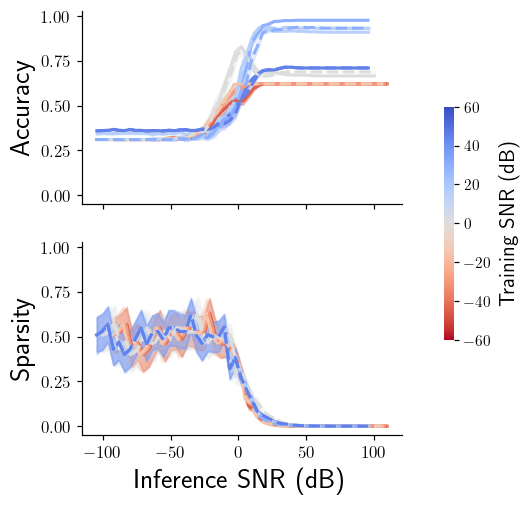

In [23]:
# plot accuracy vs snr across training snr values
unique_train_snrs = var_loss_data["training_snr"].unique()
min_train_snr = min(unique_train_snrs)
max_train_snr = max(unique_train_snrs)
print(f"Training SNR Range: {min_train_snr} to {max_train_snr}")

flare_pal = sns.color_palette("flare", len(unique_train_snrs))
crest_pal = sns.color_palette("crest", len(unique_train_snrs))
grey_pal = sns.color_palette("Greys", len(unique_train_snrs))
coolwarm_pal = sns.color_palette("coolwarm_r", len(unique_train_snrs))

# adding colorbars to the right
norm = mpl.colors.Normalize(vmin=-60, vmax=60)
sm = plt.cm.ScalarMappable(cmap="coolwarm_r", norm=norm) # make sure that this is the same as the palette used in the lineplot

fig, ax = plt.subplots(2, 1, figsize=(5, 5), sharex=True, sharey=True, dpi=110)

# adding colorbar
cbar = fig.colorbar(sm, ax=[ax[0], ax[1]], orientation='vertical', pad=0.1, aspect=25, shrink=0.55)
cbar.set_label("Training SNR (dB)", fontsize=14, labelpad=5)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=10)


# top plot: accuracy vs snr
sns.lineplot(data=var_loss_data_a_4, 
                x="snr", 
                y="accuracy",
                hue="training_snr", 
                palette=coolwarm_pal, 
                ax=ax[0], 
                legend=False,
                lw=2)

sns.lineplot(data=var_loss_data_a_2, 
                x="snr", 
                y="accuracy",
                hue="training_snr", 
                palette=coolwarm_pal, 
                ax=ax[0], 
                legend=False,
                lw=2,
                ls="--")

ax[0].set_ylabel("Accuracy", fontsize=18)
ax[0].tick_params(axis='both', labelsize=11)

# bottom plot: sparsity vs snr
sns.lineplot(data=var_loss_data_a_4, 
                x="snr", 
                y="sparsity",
                hue="training_snr", 
                palette=coolwarm_pal, 
                ax=ax[1], 
                legend=False,
                lw=2)

sns.lineplot(data=var_loss_data_a_2, 
                x="snr", 
                y="sparsity",
                hue="training_snr", 
                palette=coolwarm_pal, 
                ax=ax[1], 
                legend=False,
                lw=2,
                ls="--")

ax[1].set_ylabel("Sparsity", fontsize=18)
ax[1].tick_params(axis='both', labelsize=11)
ax[1].set_xlabel("Inference SNR (dB)", fontsize=18)

sns.despine(ax=ax[0])
sns.despine(ax=ax[1])



## Notes:
* Including the variance loss hasn't affected the performance by much but the sparsity hasn't increased either.
* We can plot all the values of alpha parameter together, but I doubt if that would achieve the "increase sparsity without affecting performance" effect.
* In general, we have the following options:
  1. Try out another setting for including variance loss in the model. Consistency regularization.
  2. Expanding into larger datasets to see how TriDENT performs. Maybe the fact that larger networks show more sparsity would be useful.
